<a href="https://colab.research.google.com/github/rahulakkasali/Black_shoes_model/blob/main/Black_shoes__model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
file_path=("/nifty_options_dummy_dataset.csv")

In [ ]:
df=pd.read_csv(file_path)

In [ ]:
#renaming the columns of dataset
df.rename(columns={'S': 'Stock Price',
                   'K': 'Strike Price',
                   'T': "Time to expairy",
                   'V': "Volatility"
}, inplace=True)

In [ ]:
df["Volatility"] = df["Volatility"] / 100

In [ ]:
r = 0.065  # 6.5%

In [ ]:
d1 = (np.log(df["Stock Price"] / df["Strike Price"]) + (r + 0.5 * df["Volatility"]**2) * df["Time to expairy"]) / (df["Volatility"] * np.sqrt(df["Time to expairy"]))
d2 = d1 - df["Volatility"] * np.sqrt(df["Time to expairy"])


In [ ]:
from scipy.stats import norm
df["bsm_price"] = df["Stock Price"] * norm.cdf(d1) - df["Strike Price"] * np.exp(-r * df["Time to expairy"]) * norm.cdf(d2)

In [ ]:
df.head()

,Stock Price,Strike Price,Time to expairy,Volatility,delta,gamma,theta,vega,bsm_price
0,19649.01,20093.01,0.4785,0.3214,0.4164,0.00115,-36.57,5.05,1818.595044
1,19458.52,19157.52,0.3844,0.2880,0.3561,0.00743,-9.55,18.17,1778.419948
2,19694.31,19435.31,0.4839,0.1751,0.2456,0.00103,-25.39,25.81,1428.095906
3,19956.91,19694.91,0.0275,0.1223,0.2259,0.02971,-10.84,11.09,350.805342
4,19429.75,19231.75,0.3433,0.3521,0.2200,0.00075,-20.07,9.72,1901.363592


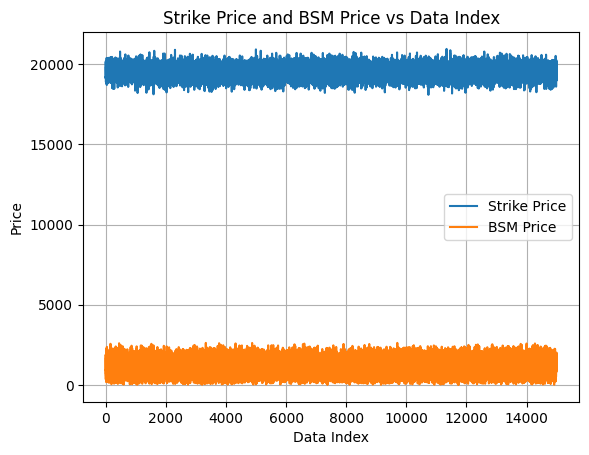

In [ ]:
import matplotlib.pyplot as plt
plt.figure()

plt.plot(df.index, df["Strike Price"], label="Strike Price")
plt.plot(df.index, df["bsm_price"], label="BSM Price")

# Labels
plt.xlabel("Data Index")
plt.ylabel("Price")
plt.title("Strike Price and BSM Price vs Data Index")

# Show legend to distinguish lines
plt.legend()

# Show grid
plt.grid()

# Show plot
plt.show()

In [ ]:
df['difference']=(df['Strike Price']-df['bsm_price'])

In [ ]:
df.head()

,Stock Price,Strike Price,Time to expairy,Volatility,delta,gamma,theta,vega,bsm_price,difference
0,19649.01,20093.01,0.4785,0.3214,0.4164,0.00115,-36.57,5.05,1818.595044,18274.414956
1,19458.52,19157.52,0.3844,0.2880,0.3561,0.00743,-9.55,18.17,1778.419948,17379.100052
2,19694.31,19435.31,0.4839,0.1751,0.2456,0.00103,-25.39,25.81,1428.095906,18007.214094
3,19956.91,19694.91,0.0275,0.1223,0.2259,0.02971,-10.84,11.09,350.805342,19344.104658
4,19429.75,19231.75,0.3433,0.3521,0.2200,0.00075,-20.07,9.72,1901.363592,17330.386408


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


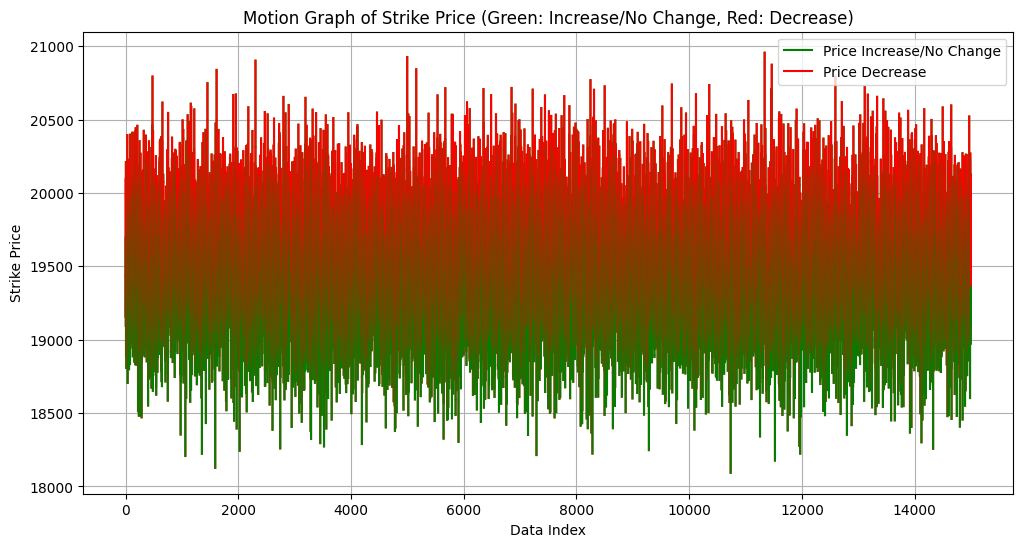

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Get the Strike Price series and index values
strike_price = df["Strike Price"]
index_values = df.index

# Plotting segments with different colors based on price movement
for i in range(len(strike_price) - 1):
    x_coords = [index_values[i], index_values[i+1]]
    y_coords = [strike_price.iloc[i], strike_price.iloc[i+1]]

    if strike_price.iloc[i+1] >= strike_price.iloc[i]:
        plt.plot(x_coords, y_coords, color='green')
    else:
        plt.plot(x_coords, y_coords, color='red')

# Create dummy plots for a proper legend
plt.plot([], [], color='green', label='Price Increase/No Change')
plt.plot([], [], color='red', label='Price Decrease')

plt.xlabel("Data Index")
plt.ylabel("Strike Price")
plt.title("Motion Graph of Strike Price (Green: Increase/No Change, Red: Decrease)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_348/2846085492.py:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


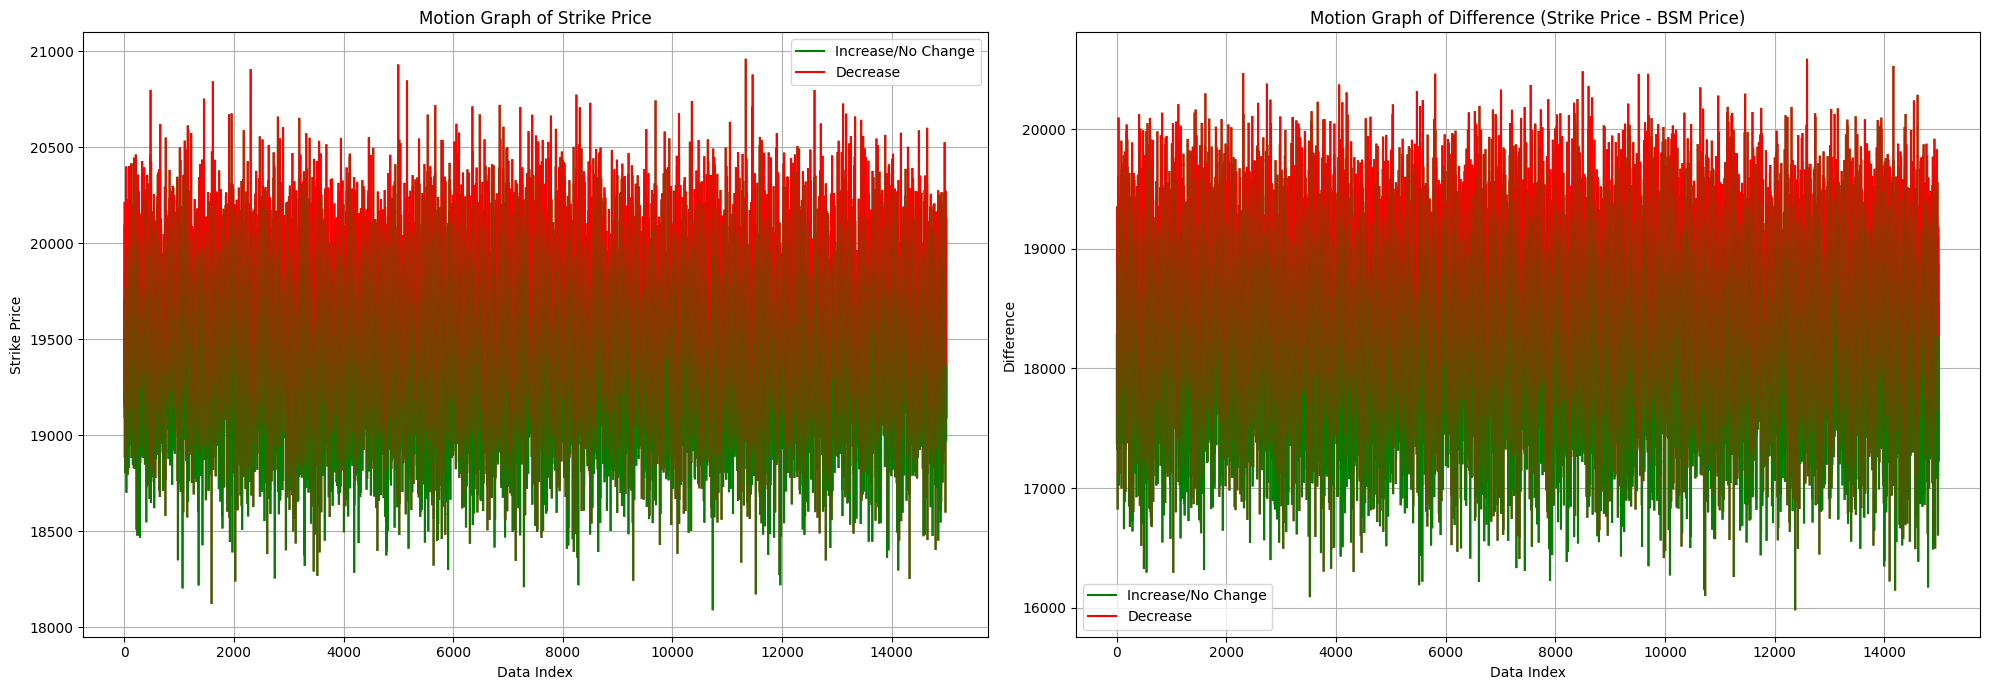

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Plot for Strike Price Motion ---
ax1 = axes[0]
strike_price = df["Strike Price"]
index_values = df.index

for i in range(len(strike_price) - 1):
    x_coords = [index_values[i], index_values[i+1]]
    y_coords = [strike_price.iloc[i], strike_price.iloc[i+1]]

    if strike_price.iloc[i+1] >= strike_price.iloc[i]:
        ax1.plot(x_coords, y_coords, color='green')
    else:
        ax1.plot(x_coords, y_coords, color='red')

ax1.plot([], [], color='green', label='Increase/No Change')
ax1.plot([], [], color='red', label='Decrease')

ax1.set_xlabel("Data Index")
ax1.set_ylabel("Strike Price")
ax1.set_title("Motion Graph of Strike Price")
ax1.legend()
ax1.grid(True)

# --- Plot for Difference Motion ---
ax2 = axes[1]
difference = df["difference"]

for i in range(len(difference) - 1):
    x_coords = [index_values[i], index_values[i+1]]
    y_coords = [difference.iloc[i], difference.iloc[i+1]]

    if difference.iloc[i+1] >= difference.iloc[i]:
        ax2.plot(x_coords, y_coords, color='green')
    else:
        ax2.plot(x_coords, y_coords, color='red')

ax2.plot([], [], color='green', label='Increase/No Change')
ax2.plot([], [], color='red', label='Decrease')

ax2.set_xlabel("Data Index")
ax2.set_ylabel("Difference")
ax2.set_title("Motion Graph of Difference (Strike Price - BSM Price)")
ax2.legend()
ax2.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()